In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [4]:
df = pd.read_parquet("../source_data/gold_asset_failure_risk.parquet")

In [5]:
print(df.shape)

(261, 26)


In [6]:
print(df.columns.tolist())

['hardware_pk', 'hardware_id', 'asset_name', 'uuid', 'device_age_years', 'bios_risk_level_encoded', 'worst_drive_health_encoded', 'total_drive_gb', 'drive_count', 'storage_device_count', 'high_risk_software_count', 'total_software_count', 'risk_software_ratio', 'memory_gb', 'cpu_cores', 'has_valid_ipv4', 'has_warranty', 'asset_value', 'incident_count', 'days_since_last_inventory', 'inventory_quality_tier_encoded', 'os_family', 'source_year', 'rule_based_risk_score', 'anomaly_score', 'is_anomaly']


In [7]:
df['is_anomaly'].value_counts(normalize=True)

Series([], Name: proportion, dtype: float64)

In [10]:
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing = missing[missing > 0]

print(missing)

anomaly_score    261
is_anomaly       261
dtype: int64


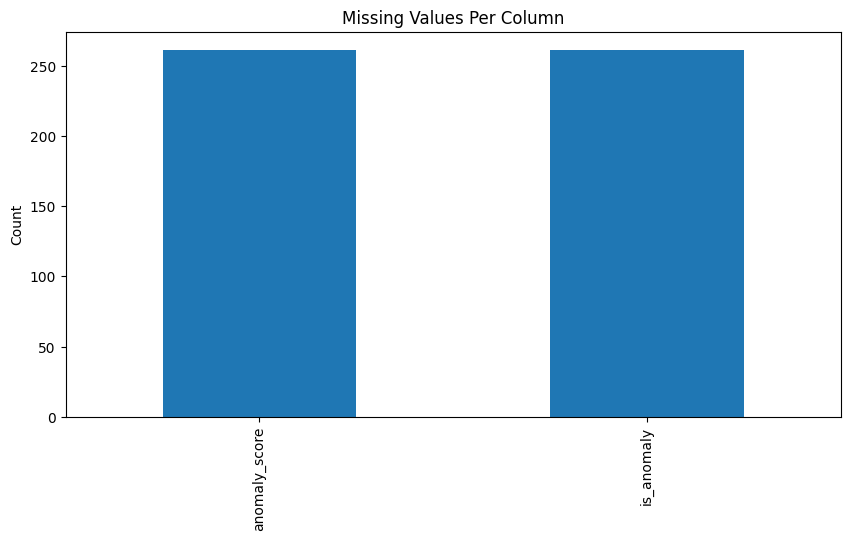

In [11]:
plt.figure(figsize=(10,5))
missing.plot(kind="bar")
plt.title("Missing Values Per Column")
plt.ylabel("Count")
plt.show()

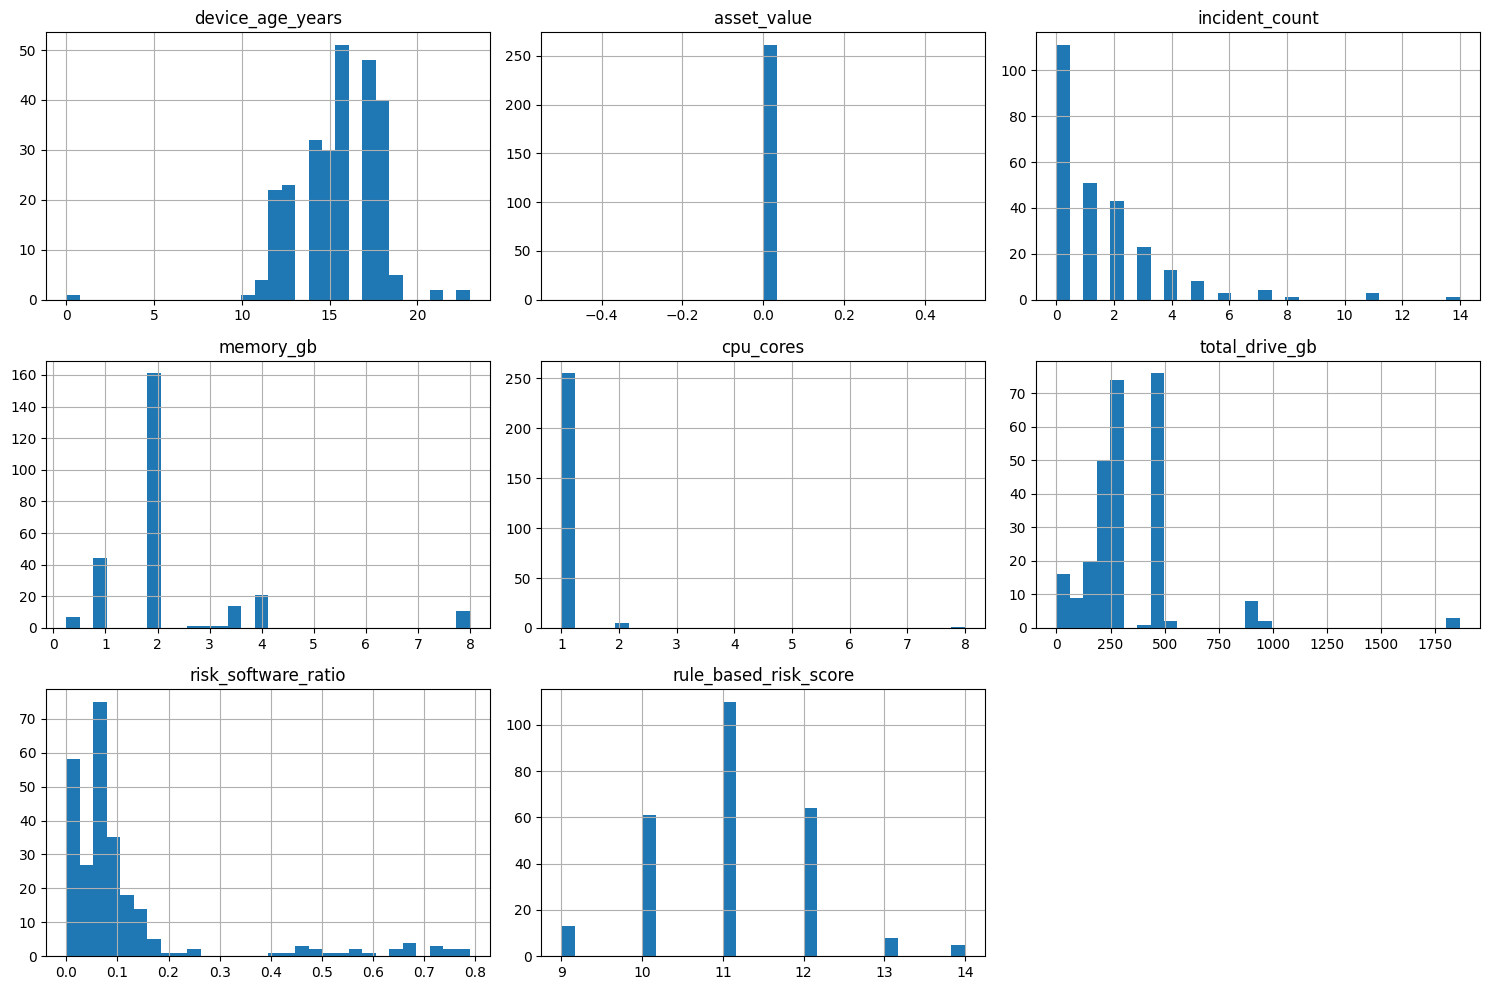

In [12]:
numerical_cols = [
    'device_age_years',
    'asset_value',
    'incident_count',
    'memory_gb',
    'cpu_cores',
    'total_drive_gb',
    'risk_software_ratio',
    'rule_based_risk_score',
    'anomaly_score'
]
df[numerical_cols].hist(
    figsize=(15,10),
    bins=30
)

plt.tight_layout()
plt.show()

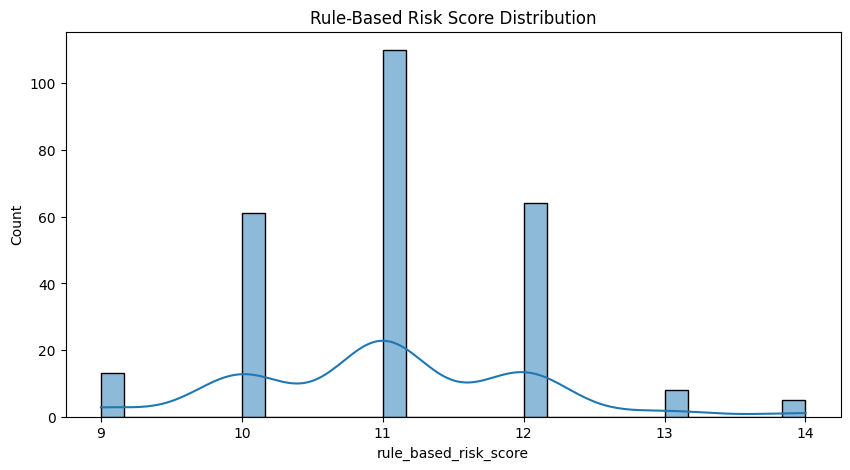

In [15]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['rule_based_risk_score'],
    bins=30,
    kde=True
)

plt.title("Rule-Based Risk Score Distribution")
plt.show()

In [17]:
top_risk = (
    df.sort_values(
        "rule_based_risk_score",
        ascending=False
    )
    .head(10)
)

top_risk[
    ['asset_name',
     'rule_based_risk_score',
     'anomaly_score']
]

,asset_name,rule_based_risk_score,anomaly_score
0,p-17041-123,14,None
216,p-18050-047,14,None
86,p-03071-236,14,None
253,p-02016-263,14,None
104,p-13089-018,14,None
51,p-13090-162,13,None
224,p-02004-188,13,None
193,p-13932-102,13,None
106,p-15083-074,13,None
74,p-18057-028,13,None


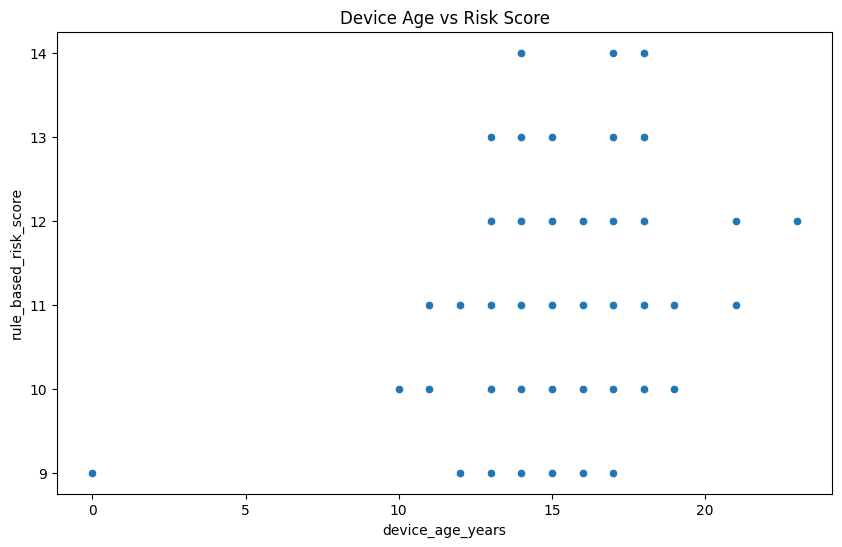

In [18]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='device_age_years',
    y='rule_based_risk_score'
)

plt.title("Device Age vs Risk Score")
plt.show()

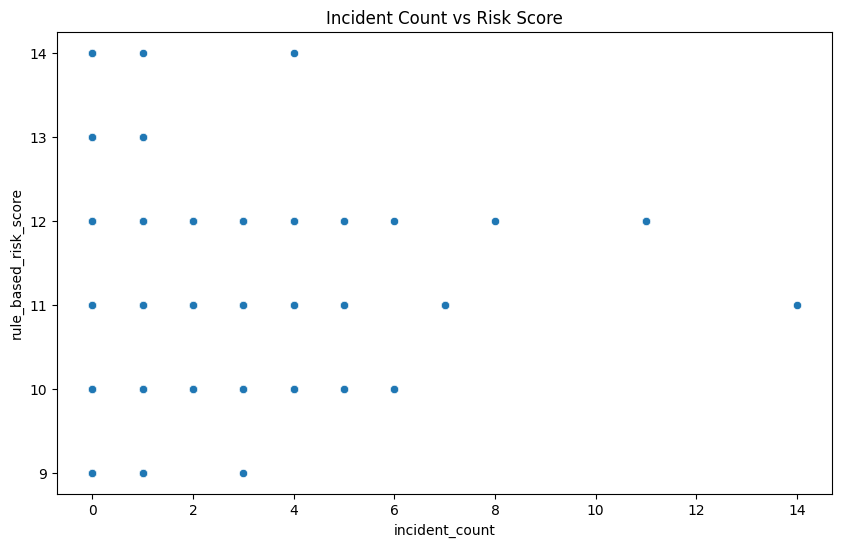

In [19]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='incident_count',
    y='rule_based_risk_score'
)

plt.title("Incident Count vs Risk Score")
plt.show()